In [2]:
import sys, os
os.path.dirname(sys.executable)

'/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/bin'

In [3]:
sys.path.append('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/')
from ESMCBA.imports import *
from ESMCBA import graph_utils
from ESMCBA import other_utils
import importlib
importlib.reload(other_utils)

<module 'ESMCBA.other_utils' from '/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py'>

In [4]:
# importlib.reload(other_utils)
# evaluations_dt = other_utils.get_all_evaluations('/global/scratch/users/sergiomar10/losses/ESMCBA_21032025/*.csv')
# evaluations_dt.to_csv('../models_performances_22032025.csv', index= False )

In [5]:
importlib.reload(other_utils)
# evaluations_dt = pd.read_csv('../models_performances_22032025.csv')
# evaluations_dt = evaluations_dt.sort_values(by=['spearman','mse'], ascending = [False, True]).reset_index(drop=True)
# evaluations_dt = evaluations_dt[(evaluations_dt['time'].str.contains('2025-04-1')) ] 
evaluations_dt2 = other_utils.get_all_evaluations('/global/scratch/users/sergiomar10/losses/ESMCBA_22042025/*.csv')
# evaluations_dt = pd.concat([evaluations_dt, evaluations_dt2], axis=0)
# evaluations_dt = evaluations_dt.reset_index(drop=True)

/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, _ = spearmanr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, _ = pearsonr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spearman_r, _ = spearmanr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:42: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_r, _ = pearsonr(df['measured'], df['prediction'])
/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/ESMCBA/other_utils.py:41: ConstantIn

In [6]:
evaluations_dt2['mse'] = evaluations_dt2['mse'].astype(float)
evaluations_dt2['pearsonr'] = evaluations_dt2['pearsonr'].astype(float)

In [7]:
evaluations_dt2 =  evaluations_dt2.sort_values(by='spearman', ascending = False)
evaluations_dt2['Model'] = evaluations_dt2['HLA'] + ' ' + evaluations_dt2['encoding']

evaluations_dt_sorted = evaluations_dt2.drop_duplicates('Model')
# evaluations_dt2 #.sort_values(by='spearman', ascending = False)

In [8]:
evaluations_dt_subset = evaluations_dt2
evaluations_dt_subset['rank_mse'] = evaluations_dt_subset.groupby('Model')['mse'].rank(ascending=True)
evaluations_dt_subset['rank_corr'] = evaluations_dt_subset.groupby('Model')['spearman'].rank(ascending=False)

# 2. Sum the ranks or any other combination you want.
evaluations_dt_subset['rank_sum'] = evaluations_dt_subset['rank_mse'] + evaluations_dt_subset['rank_corr']

# 3. Sort by rank_sum and pick the best model for each Model.
ranked_per_Model = (
    evaluations_dt2
    .sort_values('rank_sum', ascending=True)
    .drop_duplicates(subset='Model', keep='first')  
)

# ranked_per_Model = ranked_per_Model[ranked_per_Model['Model'].apply(len) == 8] 

In [9]:
evaluations_dt_sorted = ranked_per_Model[
                                         (ranked_per_Model['spearman'] > -0.01)
                                          ].sort_values(by=['spearman'], ascending = [False]).drop_duplicates('Model') #[evaluations_dt['Losses'] == 'MSE']

# evaluations_dt_sorted = evaluations_dt_sorted[evaluations_dt_sorted['HLA'].apply(len) == 8] 
# evaluations_dt_sorted[evaluations_dt_sorted['HLA'] == 'HLAA0201'].sort_values(by='spearman', ascending =False).head(5)

In [10]:
results = []
test_datasets_list = []

# Get unique HLA alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:

    if '0206' in allele:
        print(allele)

    # Load training data for the current allele
    formatted_HLA = allele.split(' ')[0]# .replace('*', '').replace(':', '').
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_HLA}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)

    if epitope_data[epitope_data["Year_submission"] < 2019].empty:
        epitope_data = epitope_data[epitope_data["Year_submission"] > 1995]
    else:
        epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for HLA
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['HLA'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "HLA": formatted_HLA,
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data),
            "encoding": evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['encoding'].values[0],
            "Model": allele,
        })
else:
    print(f"All test datasets were empty for HLA {allele}. Skipping this allele.")

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each HLA allele.
# - test_datasets_df: contains all the filtered test datasets with an HLA identifier.

A0206 HLA
A0206 epitope
All test datasets were empty for HLA C1502 HLA. Skipping this allele.


In [11]:
metrics_df = metrics_df.sort_values(by=['HLA', 'encoding'])# .#head(50)
# metrics_df÷

### Recompute the spearman and pearson without the duplicates of the training data

In [12]:
results = []
test_datasets_list = []

# Get unique Model alleles
alleles = evaluations_dt_sorted['Model'].unique()

for allele in alleles:
    # Load training data for the current allele
    formatted_Model = allele.split(' ')[0] #.replace('*', '').replace(':', '')  # e.g., ModelB0801
    train_fasta = f"/global/scratch/users/sergiomar10/data/IEDB_SQL/IEDB_HLA{formatted_Model}_final.csv"
    epitope_data = pd.read_csv(train_fasta, header=None)
    epitope_data.columns = ['sequence', 'ref_ID', 'submissionID', 'Epitope_ID', 'protein_origin', 
                            'ID_SOURCE', 'SOURCE_ORGANISM', 'IC50_nM', 'DESCRIPTION_BINDING', 'Year_submission']
    
    # Clean and filter the training data
    epitope_data['Year_submission'] = epitope_data['Year_submission'].astype(str).replace('\\N', '0').astype(int)
    epitope_data = epitope_data[epitope_data["Year_submission"] < 2019]

    # Load test data for the current allele
    test_path = evaluations_dt_sorted[evaluations_dt_sorted['Model'] == allele]['path'].values[0]
    test_dataset = pd.read_csv(test_path)
    
    # Remove training sequences from the test data
    test_dataset = test_dataset[~test_dataset['sequence'].isin(epitope_data['sequence'])]
    
    # If the filtered test dataset is empty, skip this allele
    if test_dataset.empty:
        continue

    # Store the test dataset with an added column for Model
    test_dataset = test_dataset.copy()  # Ensure we're not modifying the original DataFrame unexpectedly
    test_dataset['Model'] = allele
    test_datasets_list.append(test_dataset)
    
    # Only compute metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        
        results.append({
            "Model": allele,
            "HLA" : formatted_Model, 
            "spearman": spearman_str,
            "pearsonr": pearson_str,
            "mse": mse_str,
            "test_size": len(test_dataset),
            "path": test_path,
            "training_data": len(epitope_data)
        })

# Create a DataFrame with the metrics results
metrics_df = pd.DataFrame(results)

# Concatenate all test datasets into a single DataFrame
if test_datasets_list:
    test_datasets_df = pd.concat(test_datasets_list, ignore_index=True)
else:
    test_datasets_df = pd.DataFrame()  # empty DataFrame if no test datasets were stored

# Now you have:
# - metrics_df: contains the computed metrics for each Model allele.
# - test_datasets_df: contains all the filtered test datasets with an Model identifier.


In [13]:
# pd.merge(left=metrics_df, right=evaluations_dt_sorted[['HLA','time','rank_mse','rank_corr', 'rank_sum']], on='HLA', how='left').sort_values(by='time').reset_index(drop=True)

### Reported Evaluation from the Training Held out dataset

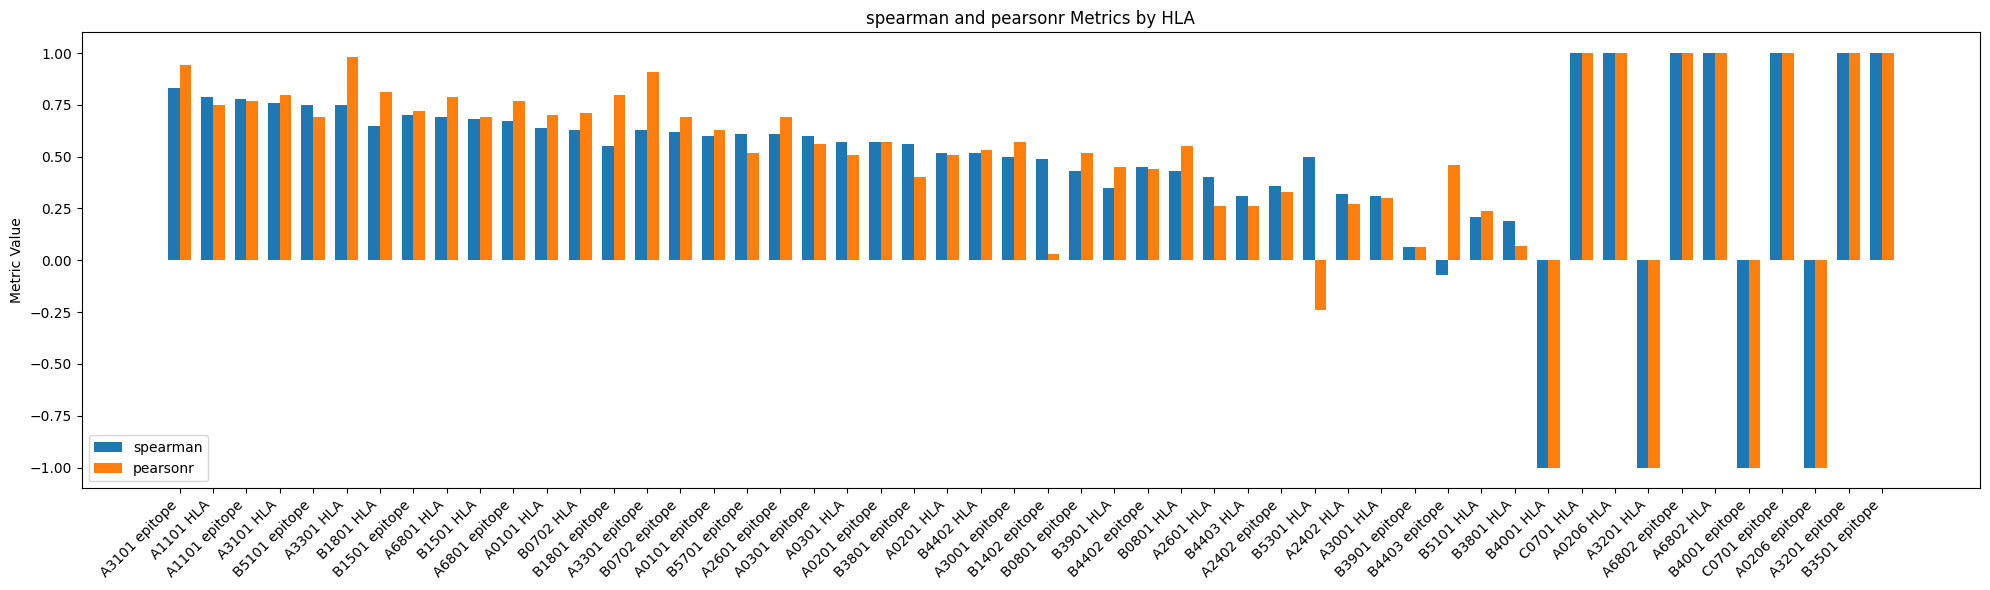

In [14]:
metrics_df['spearman'] = metrics_df['spearman'].astype(float)
metrics_df['pearsonr'] = metrics_df['pearsonr'].astype(float)

# Prepare data for plotting
hla_labels = metrics_df['Model']
spearman_vals = metrics_df['spearman']
pearsonr_vals = metrics_df['pearsonr']

x = np.arange(len(hla_labels))  # label positions
width = 0.35  # width of the bars

# Create the plot
fig, ax = plt.subplots(figsize=(20, 6))
rects1 = ax.bar(x - width/2, spearman_vals, width, label='spearman')
rects2 = ax.bar(x + width/2, pearsonr_vals, width, label='pearsonr')

# Customization: labels and title
ax.set_ylabel('Metric Value')
ax.set_title('spearman and pearsonr Metrics by HLA')
ax.set_xticks(x)
ax.set_xticklabels(hla_labels, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

In [15]:
metrics_df['mse'] = metrics_df['mse'].astype(float)

In [16]:
metrics_df['encoding'] = metrics_df['Model'].str.split(' ', expand = True)[1]

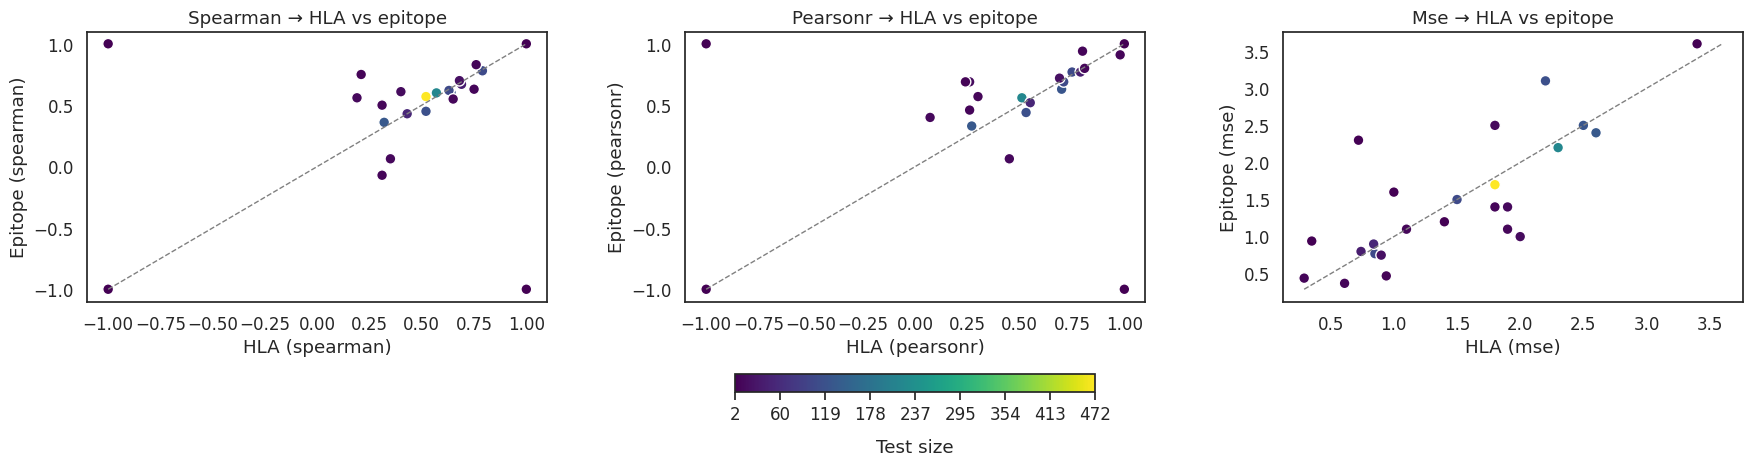

In [17]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Build the pivots without aggregation errors
keys    = ['HLA', 'test_size', 'training_data']
metrics = ['spearman','pearsonr','mse']
pivots  = {}

for m in metrics:
    pivots[m] = (
        metrics_df
          .pivot(
             index=keys,
             columns='encoding',
             values=m
          )
          .dropna()  # only keep combos where both encodings exist
          .rename(columns={
              'HLA':     'HLA_val',
              'epitope': 'epitope_val'
           })
          .reset_index()
    )

# 2) Set up normalization & colormap
norm = Normalize(
    vmin=metrics_df['test_size'].min(),
    vmax=metrics_df['test_size'].max()
)
cmap = plt.cm.viridis

# 3) Plot
sns.set(style='white', font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False, sharey=False)

for ax, m in zip(axes, metrics):
    pv = pivots[m]
    sc = ax.scatter(
        pv['HLA_val'], pv['epitope_val'],
        c=pv['test_size'], cmap=cmap, norm=norm,
        s=60, edgecolor='w'
    )

    # diagonal
    mn = min(pv['HLA_val'].min(), pv['epitope_val'].min())
    mx = max(pv['HLA_val'].max(), pv['epitope_val'].max())
    ax.plot([mn, mx], [mn, mx], '--', color='gray', lw=1)

    ax.set_title(f"{m.capitalize()} → HLA vs epitope")
    ax.set_xlabel(f"HLA ({m})")
    ax.set_ylabel(f"Epitope ({m})")

# 4) Adjust layout so nothing overlaps
fig.subplots_adjust(left=0.05, right=0.97, top=0.90, bottom=0.18, wspace=0.3)

# 5) Single horizontal colorbar underneath
cbar = fig.colorbar(
    sc, ax=axes.tolist(),
    orientation='horizontal',
    fraction=0.05,
    pad=0.2
)
# more granular ticks
levels = np.linspace(norm.vmin, norm.vmax, 9)
cbar.set_ticks(levels)
cbar.set_ticklabels([int(v) for v in levels])
cbar.set_label('Test size', labelpad=11)

plt.show()


In [18]:
metrics_df.to_csv('../../performances/models_performances_23042025.csv', index=False)

In [19]:
import numpy as np

for m in ['spearman','pearsonr','mse']:
    pv = pivots[m]
    total = len(pv)

    if m == 'mse':
        # for errors: epitope_val “wins” when its MSE is LOWER than HLA’s
        wins = np.sum(pv['epitope_val'] < pv['HLA_val'])
    else:
        # for scoring metrics: epitope_val wins when its score is HIGHER
        wins = np.sum(pv['epitope_val'] > pv['HLA_val'])

    print(f"{m}: {wins}/{total} ({wins/total:.1%}) settings where epitope_val wins")


spearman: 10/24 (41.7%) settings where epitope_val wins
pearsonr: 12/24 (50.0%) settings where epitope_val wins
mse: 12/24 (50.0%) settings where epitope_val wins


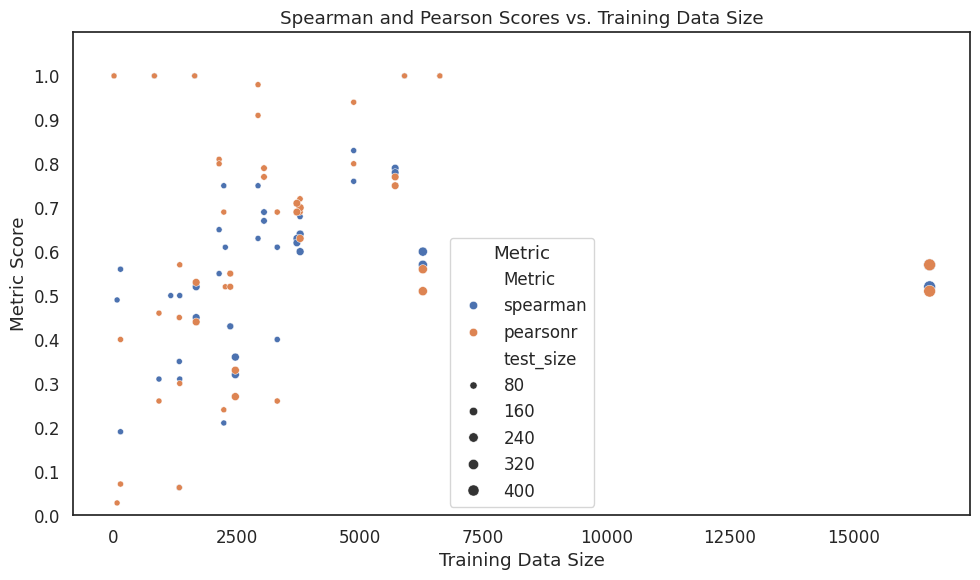

In [20]:
df_melted = metrics_df.melt(id_vars=['HLA', 'training_data', 'test_size'], 
                            value_vars=['spearman', 'pearsonr'], 
                            var_name='Metric', 
                            value_name='Score')

# Create the scatter plot using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_melted, 
                x='training_data', 
                y='Score', 
                hue='Metric', 
                size='test_size')

# plt.xscale('log10')
plt.ylim(0, 1.1)
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xlabel('Training Data Size')
plt.ylabel('Metric Score')
plt.title('Spearman and Pearson Scores vs. Training Data Size')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

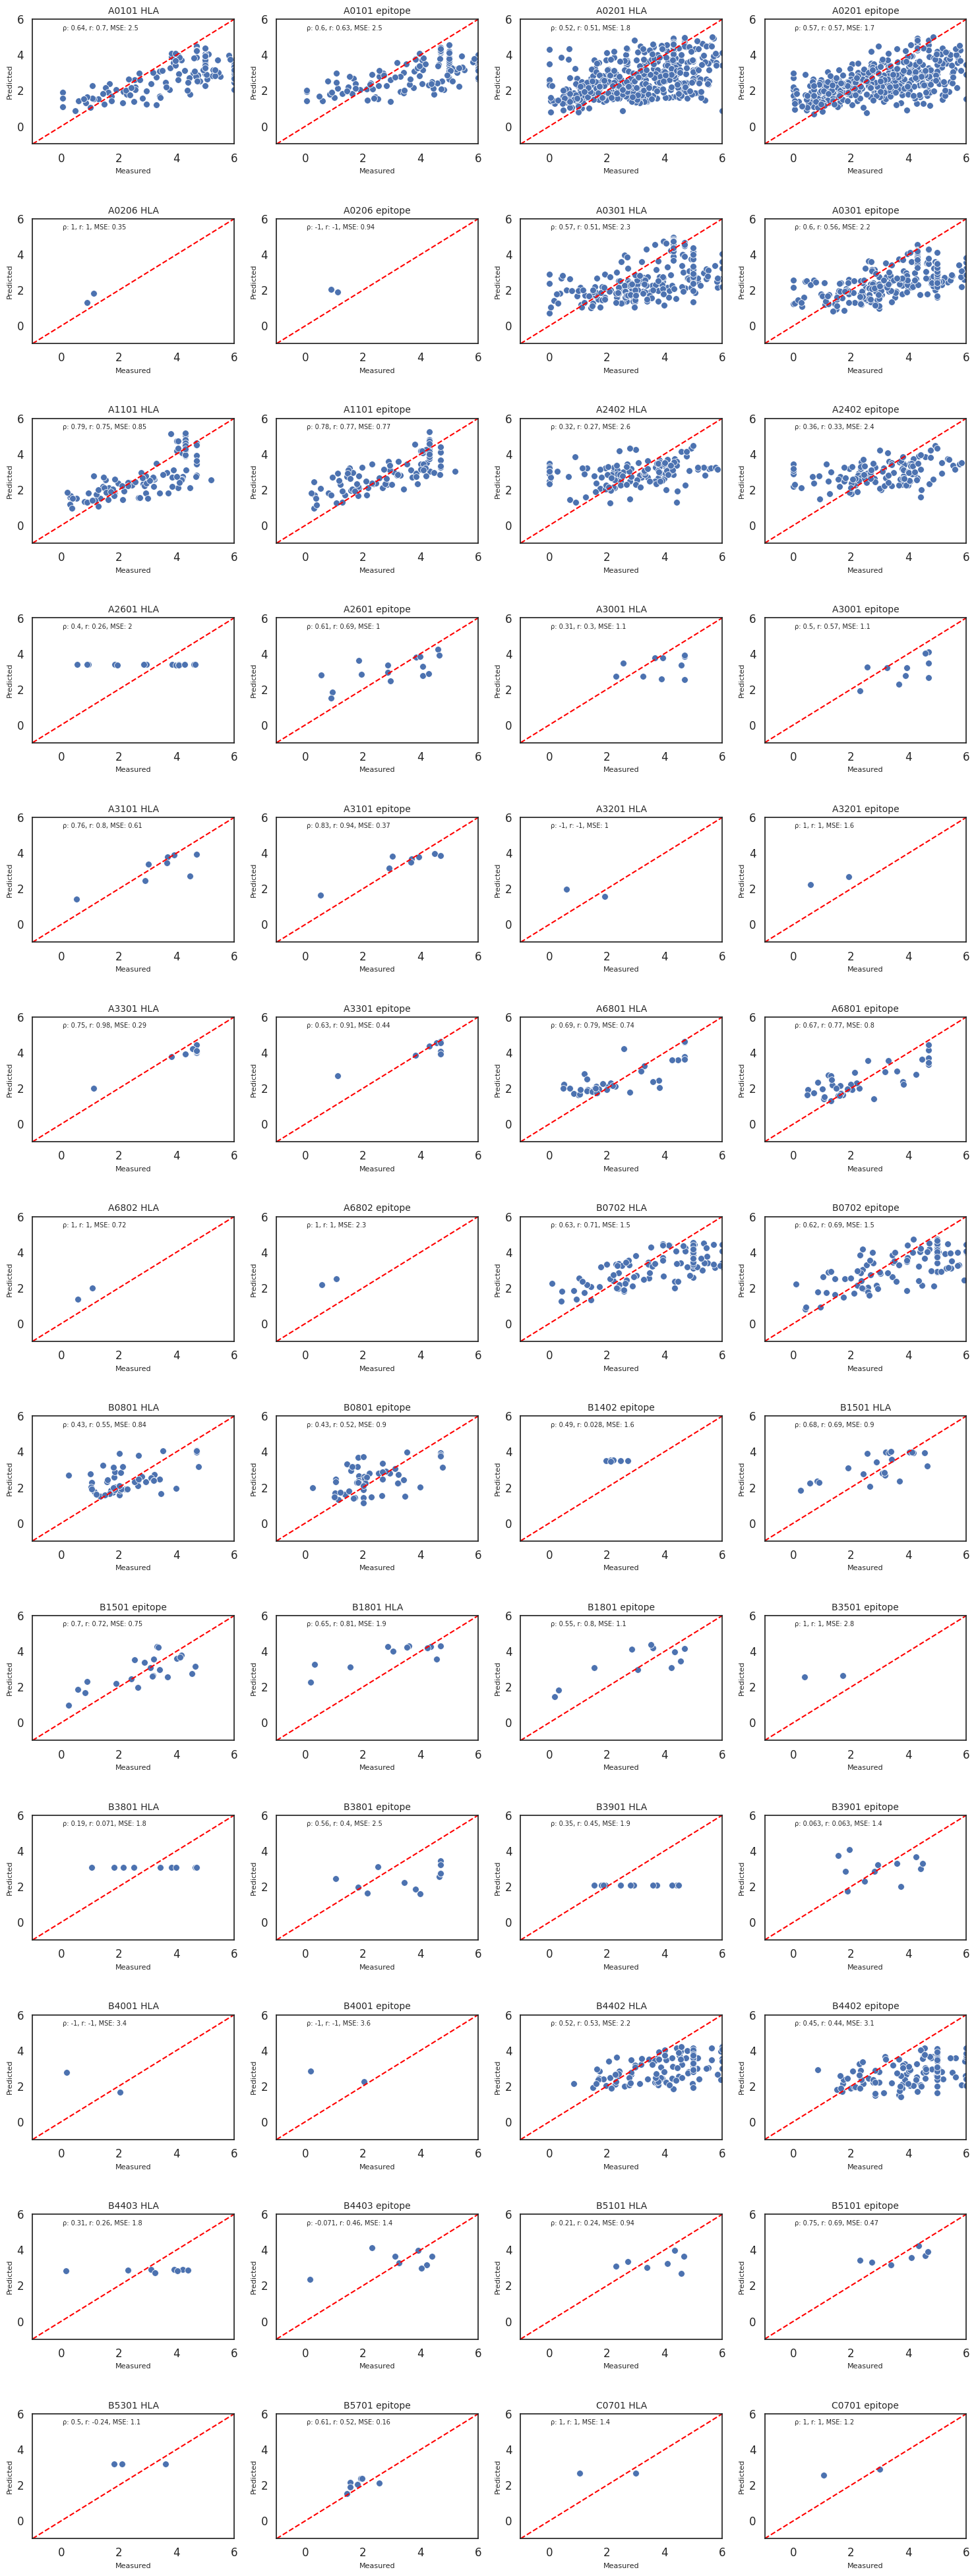

In [21]:
# Get the unique alleles from evaluations_dt_sorted
alleles = metrics_df.sort_values(by=['HLA', 'encoding'])['Model'].unique()

# Set up a grid: 11 rows x 5 columns
n_rows = 20
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 60))
axes = axes.flatten()

for i, allele in enumerate(alleles):
    if i >= len(axes):
        break

    ax = axes[i]

    # Filter the pre-stored test datasets for the current allele
    test_dataset = test_datasets_df[test_datasets_df['Model'] == allele]

    # If no test data is found, hide this subplot and continue
    if test_dataset.empty:
        ax.set_visible(False)
        continue

    # Create the scatter plot
    sns.scatterplot(data=test_dataset, x='measured', y='prediction', ax=ax, s=50)
    ax.plot([-1, 9], [-1, 9], color='red', linestyle='--', label='Identity Line')
    ax.set_ylim(-1, 6)
    ax.set_xlim(-1, 6)
    ax.set_title(f'{allele}', fontsize=10)
    ax.set_xlabel('Measured', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)

    # Compute and annotate the metrics if there is more than one sample
    if len(test_dataset) > 1:
        spearman_val = spearmanr(test_dataset['measured'], test_dataset['prediction'])[0]
        pearson_val = pearsonr(test_dataset['measured'], test_dataset['prediction'])[0]
        mse_val = mean_squared_error(test_dataset['measured'], test_dataset['prediction'])
        
        # Format the values to 2 significant figures
        spearman_str = f"{spearman_val:.2g}"
        pearson_str = f"{pearson_val:.2g}"
        mse_str = f"{mse_val:.2g}"
        # Annotate the metrics on the plot
        ax.text(0.05, 5.4, f"ρ: {spearman_str}, r: {pearson_str}, MSE: {mse_str}", fontsize=7)

# # Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.6)
plt.show()

### Testing the performance in MS Eluded Peptides (No Binding Affinity measurements)

In [22]:
# Load Data S2: Monoallelic benchmark dataset with predictions
# test_data = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/Data_S2.csv')

In [23]:
# subset = test_data[
#     (test_data['hla'] == 'HLA-A*02:03')
# ]

In [24]:
# _ = pd.read_csv('/global/scratch/users/sergiomar10/benchmark/MSE_loss/FinetunedESM/evaluation_HLAA0203_mhcflurry_unique.csv')
# _ = _[_['prediction'] != 'prediction']

In [25]:
_['prediction'] = _['prediction'].astype(float).apply(lambda x: 10**x)

TypeError: 'module' object is not subscriptable

In [ ]:
subset_plot = pd.merge(left=subset, right= _, left_on='peptide', right_on='sequence', how='inner')

/clusterfs/nilah/sergio/miniconda3/envs/ESM_cambrian/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


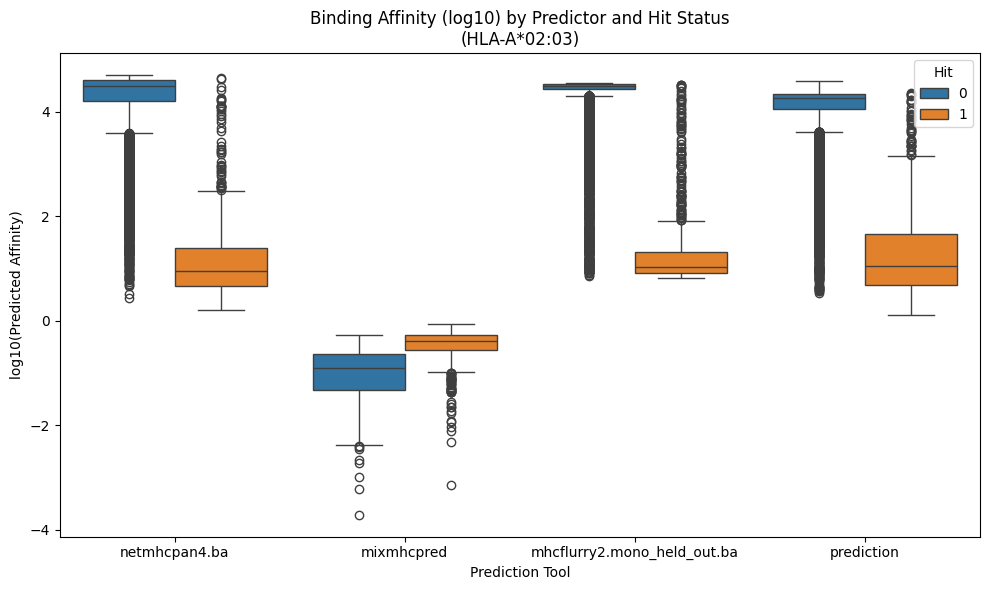

In [ ]:
# Step 2: Melt to long format
melted = subset_plot.melt(
    id_vars='hit',
    value_vars=['netmhcpan4.ba', 'mixmhcpred', 'mhcflurry2.mono_held_out.ba', 'prediction'],
    var_name='PredictionTool',
    value_name='BindingAffinity'
)

# Step 3: Apply log10 transformation
melted['log10(BA)'] = np.log10(melted['BindingAffinity'].replace(0, np.nan))  # avoid log10(0)

# Step 4: Plot violinplot split by 'hit'
plt.figure(figsize=(10, 6))
sns.boxplot(data=melted, x='PredictionTool', y='log10(BA)', hue='hit') #, split=True)
plt.title('Binding Affinity (log10) by Predictor and Hit Status\n(HLA-A*02:03)')
plt.ylabel('log10(Predicted Affinity)')
plt.xlabel('Prediction Tool')
plt.legend(title='Hit', loc='best')
plt.tight_layout()
plt.show()


### Testing on BA Affinity with epitopes - Epitopes observed in the training set of MHC Flurry were excluded by loading the S2 file

In [27]:
test_datasets_df['HLA'] = test_datasets_df['Model'].str.split(' ', expand = True)[0]

In [28]:
def compute_ppv(y_true, y_pred, threshold=np.log10(500)):
    return np.mean((y_true < threshold) & (y_pred < threshold))

# Paths
eval_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/FinetunedESM/evaluation_'
mhcflurry_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/MHCFlurry/'
netmhc_base = '/global/scratch/users/sergiomar10/benchmark/MSE_loss/NETMHCSPAN4/'

# Storage
combined_metrics = []
merged_dfs_by_HLA = {}
merged_dfs_training = {}

# Loop through unique HLAs
test_datasets_df['allele'] = test_datasets_df['HLA'].str.split(' ', expand =True)[0]

for HLA in test_datasets_df['allele'].unique():
    try:
        formatted_HLA = 'HLA' +  HLA #.replace("HLA-", "").replace("*", "").replace(":", "")
        mhc_path = f"{mhcflurry_base}{formatted_HLA}_mhc_flurry.csv"

        netmhc_path_name = formatted_HLA.replace('HLA','HLA-')
        netmhc_path_name = 'HLA-' +  HLA

        netmhc_path = f"{netmhc_base}{netmhc_path_name}_netmhc.xls"

        # Start from the ground truth + ESMC predictions
        fine_tuned_df = test_datasets_df[test_datasets_df['allele'] == HLA].copy()
        merged_df = fine_tuned_df.copy()

        # Try loading and merging MHCflurry
        if os.path.exists(mhc_path):
            mhc_pred = pd.read_csv(mhc_path)
            if 'affinity' in mhc_pred.columns:
                mhc_pred = mhc_pred.rename(columns={'affinity': 'mhcflurry_affinity'})
            merged_df = pd.merge(merged_df, mhc_pred, left_on='sequence', right_on='peptide', how='left')
            merged_df['mhc_log'] = merged_df['mhcflurry_affinity'].replace(0, np.nan).apply(np.log10)
        else:
            print(f"⚠️ MHCflurry file missing for {HLA}, skipping MHCflurry metrics.")

        # Try loading and merging NetMHCpan
        if os.path.exists(netmhc_path):
            netmhc_df = pd.read_csv(netmhc_path, sep='\t', header=1)
            netmhc_df.columns = netmhc_df.columns.str.strip()
            if 'Peptide' in netmhc_df.columns and 'BA_Rank' in netmhc_df.columns:
                netmhc_df['netmhc_log'] = netmhc_df['BA_Rank'].replace(0, np.nan).apply(np.log10)
                merged_df = pd.merge(merged_df, netmhc_df[['Peptide', 'netmhc_log']],
                                     left_on='sequence', right_on='Peptide', how='left')
        else:
            print(f"⚠️ NetMHCpan file missing for {HLA}, skipping NetMHCpan metrics.")

        # Clean
        merged_df = merged_df.drop_duplicates('sequence')
        merged_df = merged_df.dropna(subset=['measured', 'prediction'])

        if len(merged_df) == 0:
            print(f"⚠️ No usable data for {HLA}")
            continue

        label = formatted_HLA

        # --------- Fine-tuned ESMC ---------
        sp_esmc, _ = spearmanr(merged_df['measured'], merged_df['prediction'])
        pr_esmc, _ = pearsonr(merged_df['measured'], merged_df['prediction'])
        ppv_esmc = compute_ppv(merged_df['measured'], merged_df['prediction'])

        combined_metrics.append({
            'allele': formatted_HLA,
            'model': 'Fine-tuned ESMC',
            'label': label,
            'spearman': sp_esmc,
            'spearman_std': 0,
            'pearson': pr_esmc,
            'pearson_std': 0,
            'ppv': ppv_esmc,
            'ppv_std': 0
        })

        # --------- MHCflurry ---------
        if 'mhc_log' in merged_df.columns:
            mhc_valid = merged_df.dropna(subset=['mhc_log'])
            if len(mhc_valid) > 0:
                sp_mhc, _ = spearmanr(mhc_valid['measured'], mhc_valid['mhc_log'])
                pr_mhc, _ = pearsonr(mhc_valid['measured'], mhc_valid['mhc_log'])
                ppv_mhc = compute_ppv(mhc_valid['measured'], mhc_valid['mhc_log'])

                combined_metrics.append({
                    'allele': formatted_HLA,
                    'model': 'MHC Flurry',
                    'label': label,
                    'spearman': sp_mhc,
                    'spearman_std': 0,
                    'pearson': pr_mhc,
                    'pearson_std': 0,
                    'ppv': ppv_mhc,
                    'ppv_std': 0
                })

        # --------- NetMHCpan ---------
        if 'netmhc_log' in merged_df.columns:
            netmhc_valid = merged_df.dropna(subset=['netmhc_log'])
            if len(netmhc_valid) > 0:
                sp_net, _ = spearmanr(netmhc_valid['measured'], netmhc_valid['netmhc_log'])
                pr_net, _ = pearsonr(netmhc_valid['measured'], netmhc_valid['netmhc_log'])
                ppv_net = compute_ppv(netmhc_valid['measured'], netmhc_valid['netmhc_log'])

                combined_metrics.append({
                    'allele': formatted_HLA,
                    'model': 'NetMHCpan',
                    'label': label,
                    'spearman': sp_net,
                    'spearman_std': 0,
                    'pearson': pr_net,
                    'pearson_std': 0,
                    'ppv': ppv_net,
                    'ppv_std': 0
                })

        # Store merged data
        merged_dfs_by_HLA[formatted_HLA] = merged_df
        merged_dfs_training[formatted_HLA] = fine_tuned_df

    except Exception as e:
        print(f"❌ Error processing {HLA}: {e}")


⚠️ MHCflurry file missing for A0205, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for A0205, skipping NetMHCpan metrics.
⚠️ MHCflurry file missing for B1402, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for B1402, skipping NetMHCpan metrics.
⚠️ MHCflurry file missing for B5301, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for B5301, skipping NetMHCpan metrics.
⚠️ MHCflurry file missing for C0602, skipping MHCflurry metrics.
⚠️ NetMHCpan file missing for C0602, skipping NetMHCpan metrics.
❌ Error processing C0602: `x` and `y` must have length at least 2.
❌ Error processing A0206: `x` and `y` must have length at least 2.


In [29]:
combined_df = pd.DataFrame(combined_metrics)

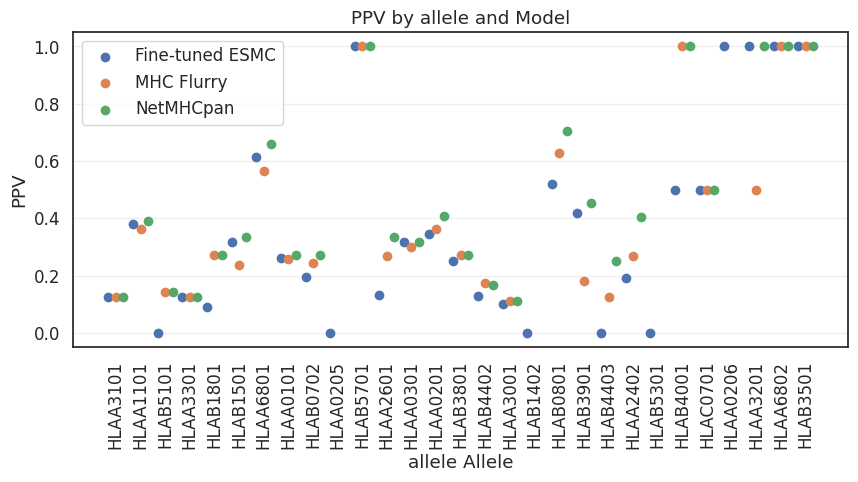

In [30]:
def plot_ppv_side_by_side(combined_df):
    # Extract unique categories for allele and model.
    unique_allele = combined_df['allele'].unique()
    unique_models = combined_df['model'].unique()
    
    # Set up the figure size (adjust as needed).
    plt.figure(figsize=(10, 5))
    
    # We'll place each category (allele) on an integer tick: 0, 1, 2, ...
    x_positions = np.arange(len(unique_allele))
    
    # Compute horizontal offsets so each model is scattered side-by-side at each x-position.
    # For example, if there are 3 models, offsets might be [-0.2, 0.0, 0.2].
    n_models = len(unique_models)
    offsets = np.linspace(-0.3, 0.3, n_models)
    
    # Loop over each model and plot points with a distinct horizontal offset
    for offset, model in zip(offsets, unique_models):
        # Filter rows for this specific model
        subset = combined_df[combined_df['model'] == model]
        
        x_vals = []
        y_vals = []
        
        # Collect the PPV values for each allele in the correct x-position
        for i, allele in enumerate(unique_allele):
            # Subset further by allele
            allele_subset = subset[subset['allele'] == allele]
            # It's possible there are multiple rows per allele if you store replicate info differently
            # so we plot them all. If there's only one row, it will simply add one point.
            for ppv_val in allele_subset['ppv'].values:
                x_vals.append(i + offset)
                y_vals.append(ppv_val)
        
        # Plot these points for the current model
        plt.scatter(x_vals, y_vals, label=model)
    
    # Set the x-ticks to the integer positions and label them with the allele names
    plt.xticks(x_positions, unique_allele, rotation=90)
    
    # Add some spacing at the bottom if labels are long
    plt.subplots_adjust(bottom=0.25)
    
    # Add labels and title
    plt.xlabel("allele Allele")
    plt.ylabel("PPV")
    plt.title("PPV by allele and Model")
    
    # Optionally add a light grid on the y-axis for clarity
    plt.grid(axis='y', alpha=0.3)
    
    # Add a legend
    plt.legend()
    
    # Show the figure
    plt.show()

# Example usage:
plot_ppv_side_by_side(combined_df)


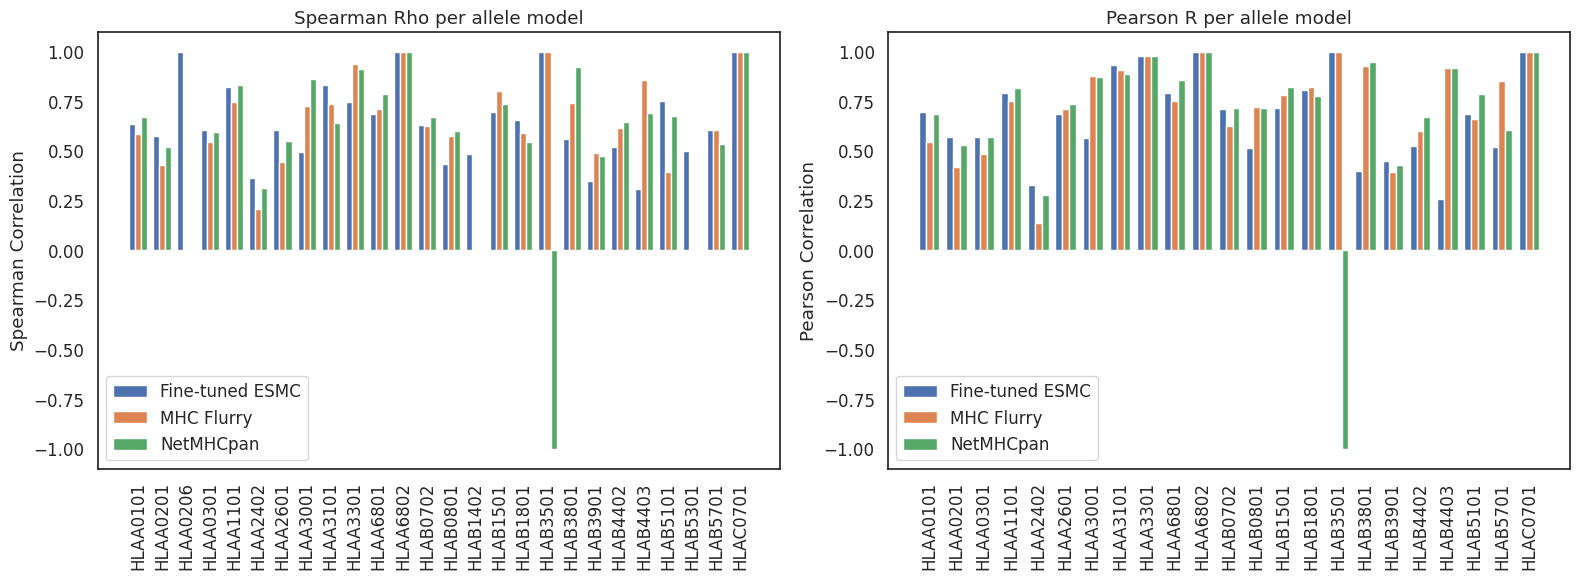

In [31]:
# Pivot tables for correlations (no std anymore)
pivot_spearman = combined_df.pivot(index='allele', columns='model', values='spearman')
pivot_spearman = pivot_spearman[pivot_spearman['Fine-tuned ESMC'] > 0 ]
pivot_pearson  = combined_df.pivot(index='allele', columns='model', values='pearson')
pivot_pearson = pivot_pearson[pivot_pearson['Fine-tuned ESMC'] > 0 ]

pivot_pearson = pivot_pearson[pivot_pearson['NetMHCpan'].notna()]

# X-axis positions
x = np.arange(len(pivot_spearman.index))
width = 0.25  # Width of each bar

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Spearman correlations
axes[0].bar(x - width, pivot_spearman['Fine-tuned ESMC'], width, label='Fine-tuned ESMC')
axes[0].bar(x,         pivot_spearman['MHC Flurry'],      width, label='MHC Flurry')
axes[0].bar(x + width, pivot_spearman['NetMHCpan'],       width, label='NetMHCpan')

axes[0].set_xticks(x)
axes[0].set_xticklabels(pivot_spearman.index, rotation=90)
axes[0].set_ylabel('Spearman Correlation')
axes[0].set_title('Spearman Rho per allele model')
axes[0].legend()


x = np.arange(len(pivot_pearson.index))
# Plot Pearson correlations
axes[1].bar(x - width, pivot_pearson['Fine-tuned ESMC'], width, label='Fine-tuned ESMC')
axes[1].bar(x,         pivot_pearson['MHC Flurry'],      width, label='MHC Flurry')
axes[1].bar(x + width, pivot_pearson['NetMHCpan'],       width, label='NetMHCpan')

axes[1].set_xticks(x)
axes[1].set_xticklabels(pivot_pearson.index, rotation=90)
axes[1].set_ylabel('Pearson Correlation')
axes[1].set_title('Pearson R per allele model')
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
model_predictions = pd.concat(merged_dfs_by_HLA.values(), ignore_index=True)

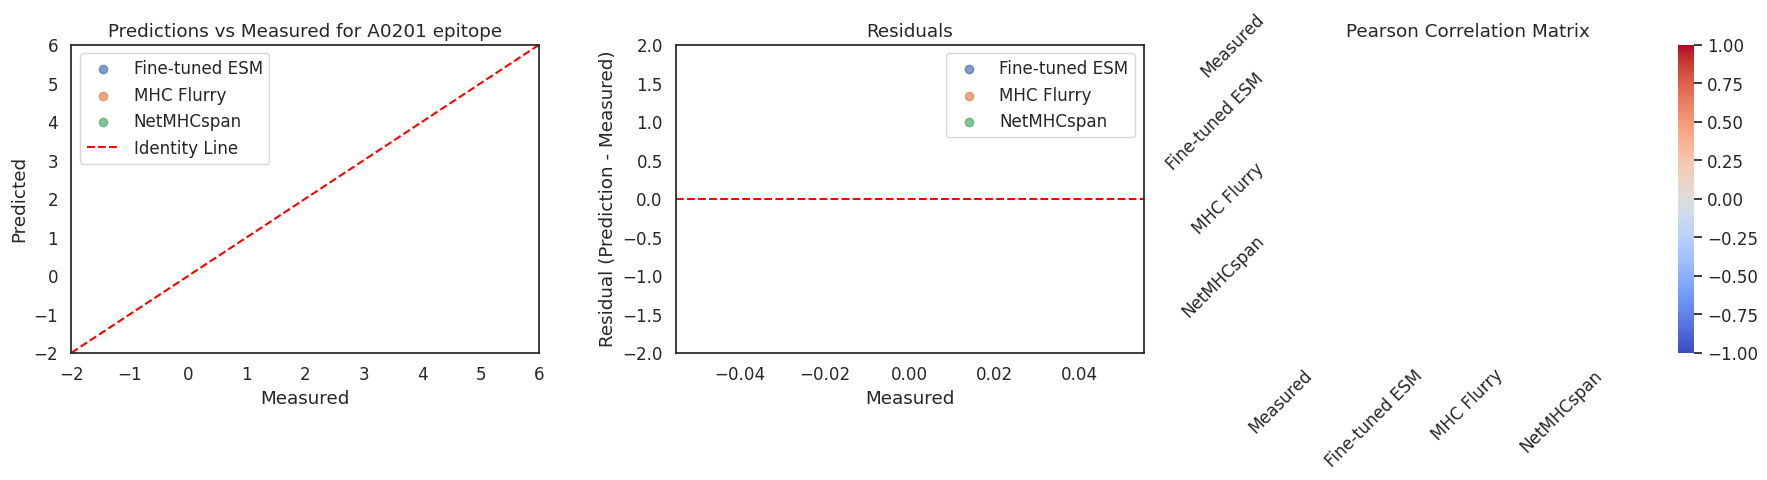

In [33]:
allele = 'A0201 epitope' #HLAA1101
df_filtered = model_predictions[model_predictions['HLA'] == allele]
df_filtered = df_filtered[['measured', 'prediction', 'mhc_log','netmhc_log']]
df_filtered.columns = ['Measured', 'Fine-tuned ESM', 'MHC Flurry', 'NetMHCspan']

# Plotting
x = 'Measured'
ys = ['Fine-tuned ESM', 'MHC Flurry', 'NetMHCspan']


# Setup the figure with subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scatter plot with identity line
for y_col in ys:
    axs[0].scatter(df_filtered[x], df_filtered[y_col], label=y_col, alpha=0.7)

axs[0].plot([-2, 6], [-2, 6], color='red', linestyle='--', label='Identity Line')
axs[0].set_title(f'Predictions vs Measured for {allele}')
axs[0].set_xlabel('Measured')
axs[0].set_ylabel('Predicted')
axs[0].set_xlim(-2, 6)
axs[0].set_ylim(-2, 6)
axs[0].legend()
# axs[0].grid(True)

# Plot 2: Residuals (Prediction - Measured)
for y_col in ys:
    residuals = df_filtered[y_col] - df_filtered[x]
    axs[1].scatter(df_filtered[x], residuals, label=y_col, alpha=0.7)

axs[1].axhline(0, color='red', linestyle='--')
axs[1].set_title('Residuals')
axs[1].set_xlabel('Measured')
axs[1].set_ylabel('Residual (Prediction - Measured)')
axs[1].set_ylim(-2, 2)
axs[1].legend()
# axs[1].grid(True)

correlation = df_filtered[[x] + ys].corr()
# Plot using seaborn
sns.heatmap(correlation, cmap='coolwarm', annot=True, vmin=-1, vmax=1, ax=axs[2])
axs[2].set_title('Pearson Correlation Matrix')
# Add colorbar and text labels
# fig.colorbar(im, ax=axs[2])
axs[2].set_xticks(range(len(correlation.columns)))
axs[2].set_yticks(range(len(correlation.columns)))
axs[2].set_xticklabels(correlation.columns, rotation=45)
axs[2].set_yticklabels(correlation.columns, rotation = 45)
axs[2].set_title('Pearson Correlation Matrix')

plt.tight_layout()
plt.show()



In [34]:
combined_df

,allele,model,label,spearman,spearman_std,pearson,pearson_std,ppv,ppv_std
0,HLAA3101,Fine-tuned ESMC,HLAA3101,0.833333,0,0.935543,0,0.125000,0
1,HLAA3101,MHC Flurry,HLAA3101,0.738095,0,0.910553,0,0.125000,0
2,HLAA3101,NetMHCpan,HLAA3101,0.642857,0,0.888455,0,0.125000,0
3,HLAA1101,Fine-tuned ESMC,HLAA1101,0.822250,0,0.794291,0,0.380000,0
4,HLAA1101,MHC Flurry,HLAA1101,0.745437,0,0.753845,0,0.363636,0
...,...,...,...,...,...,...,...,...,...
74,HLAA6802,MHC Flurry,HLAA6802,1.000000,0,1.000000,0,1.000000,0
75,HLAA6802,NetMHCpan,HLAA6802,1.000000,0,1.000000,0,1.000000,0
76,HLAB3501,Fine-tuned ESMC,HLAB3501,1.000000,0,1.000000,0,1.000000,0
77,HLAB3501,MHC Flurry,HLAB3501,1.000000,0,1.000000,0,1.000000,0


In [35]:
# model_predictions.to_csv('/global/scratch/users/sergiomar10/ESMCBA/ESMCBA/performances/HLAA0201_predictions.csv', index=False)

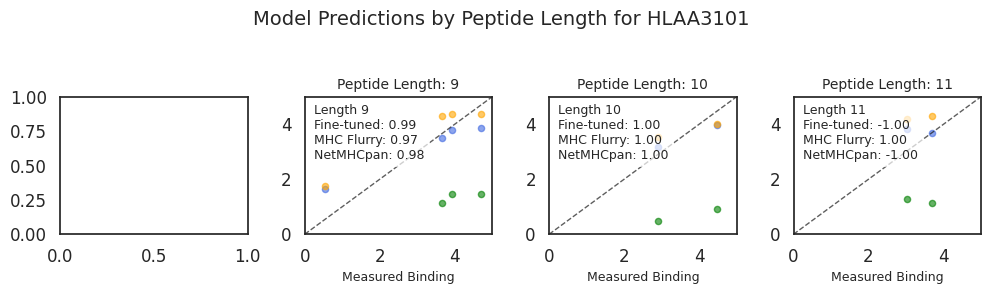

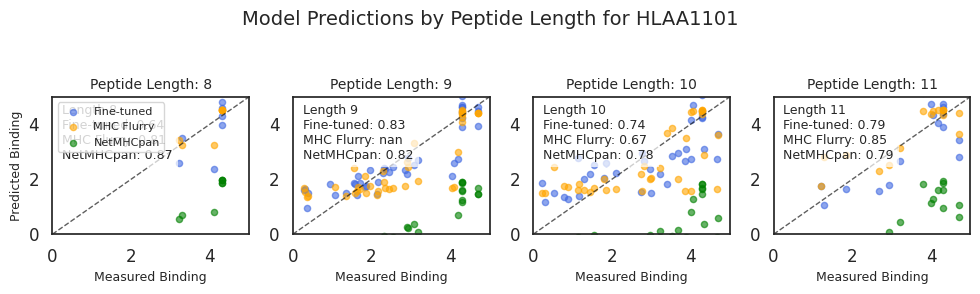

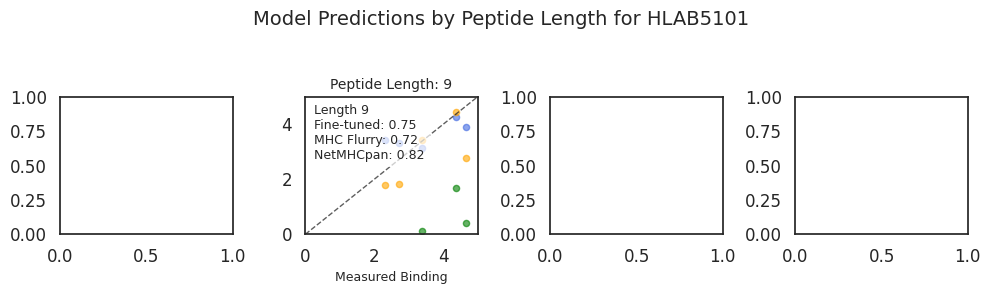

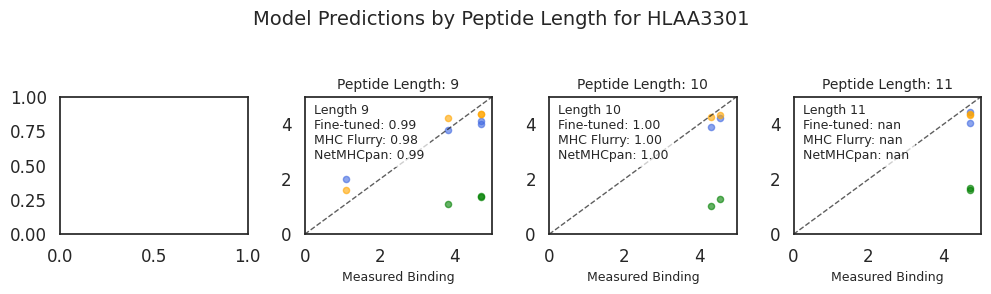

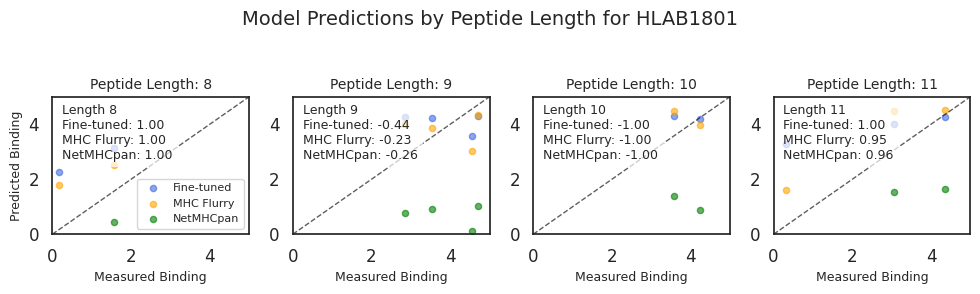

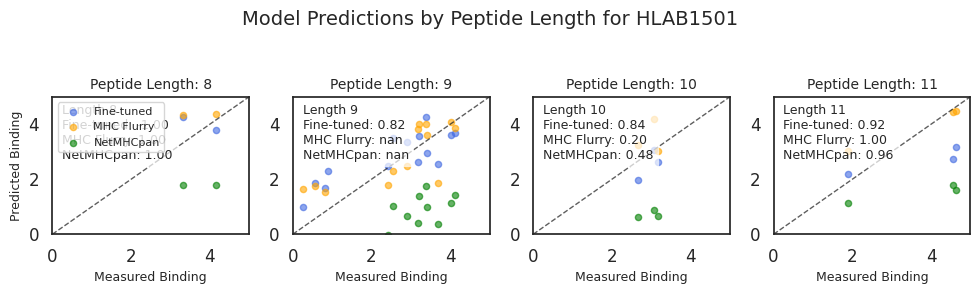

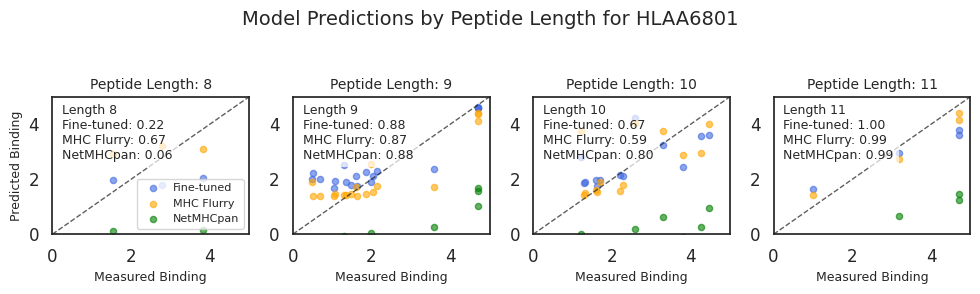

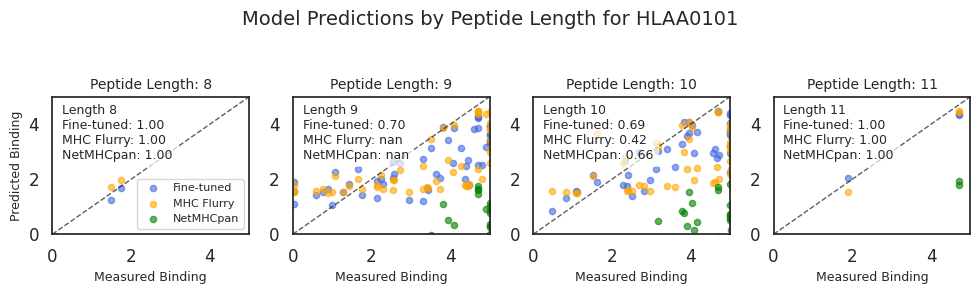

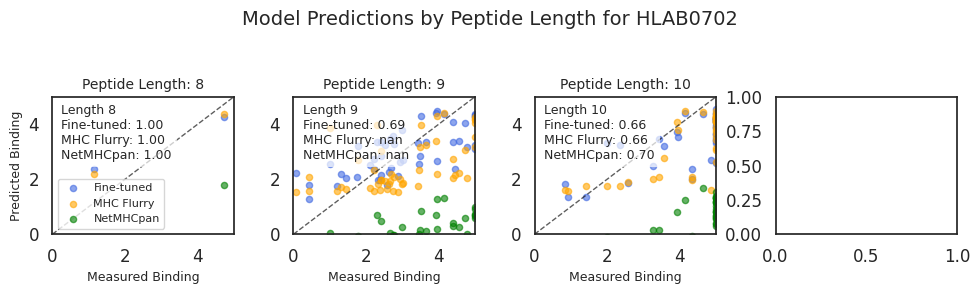

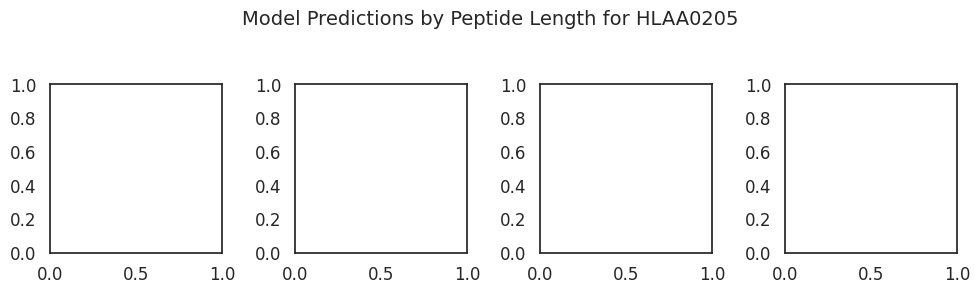

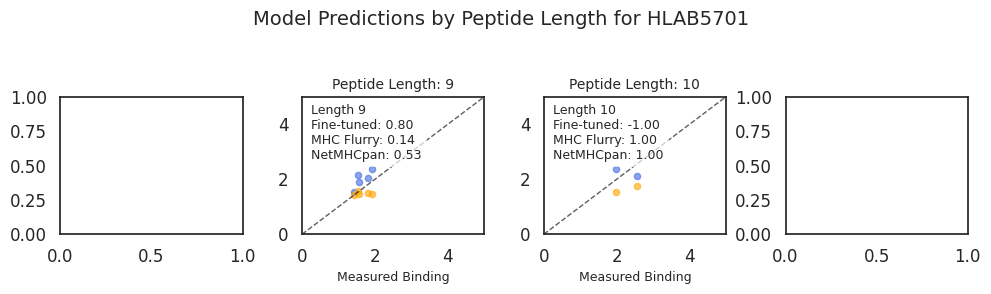

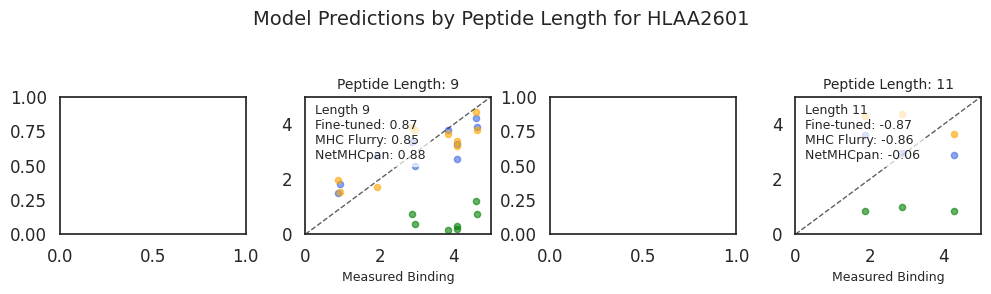

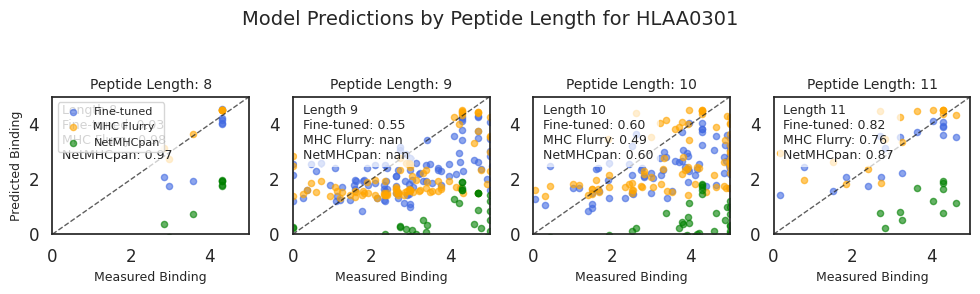

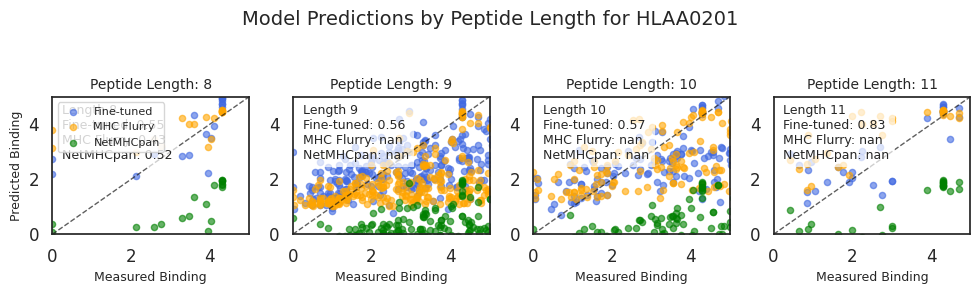

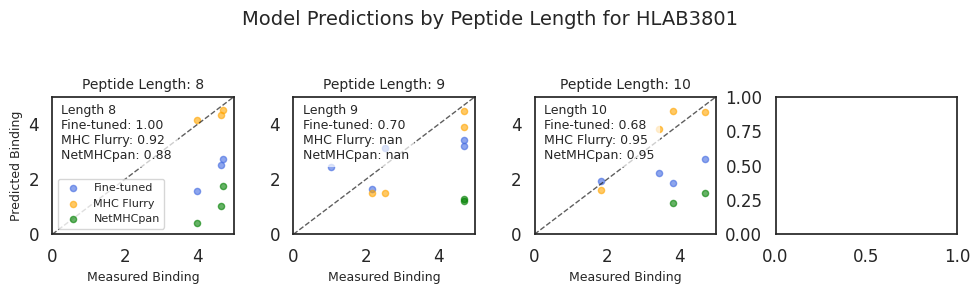

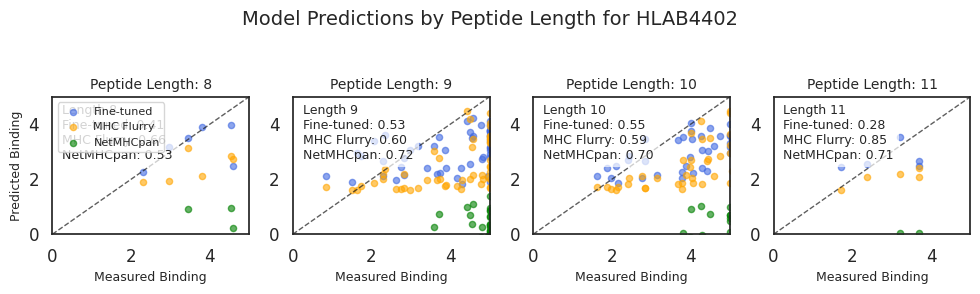

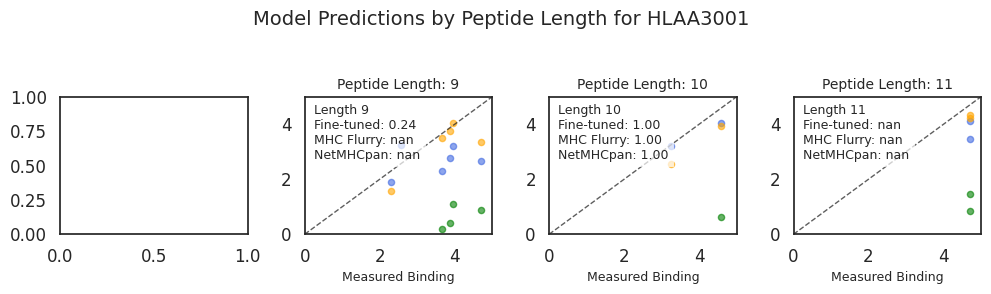

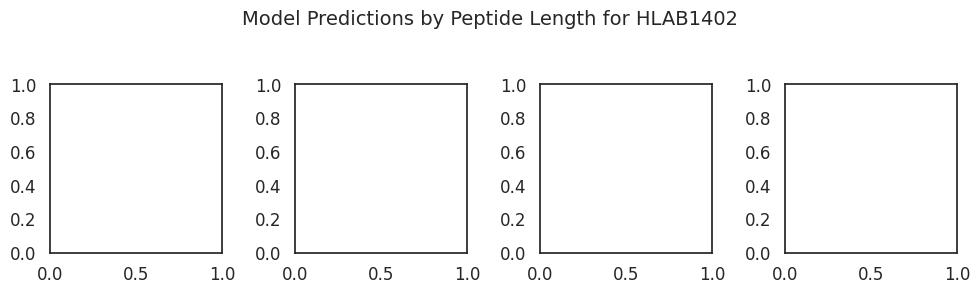

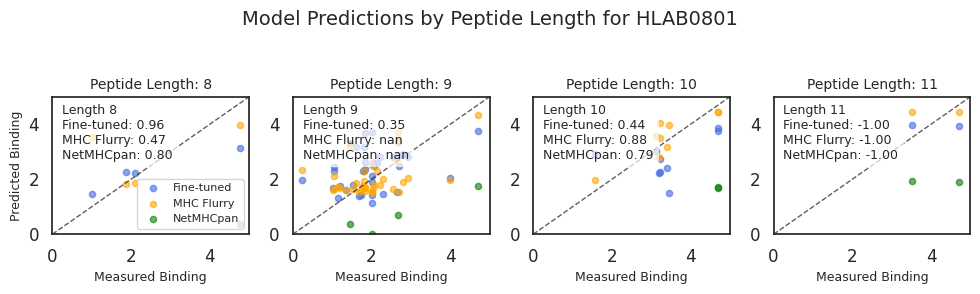

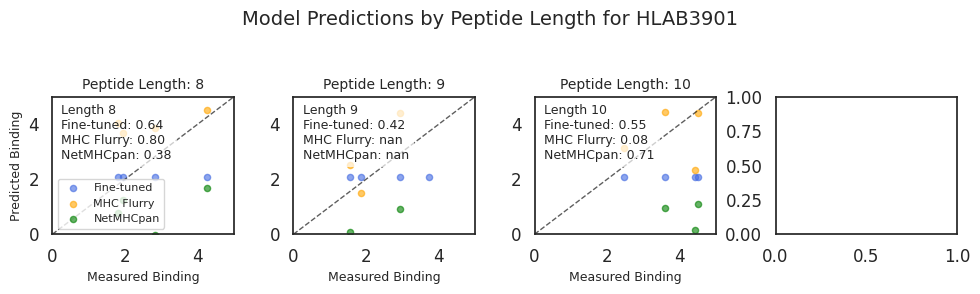

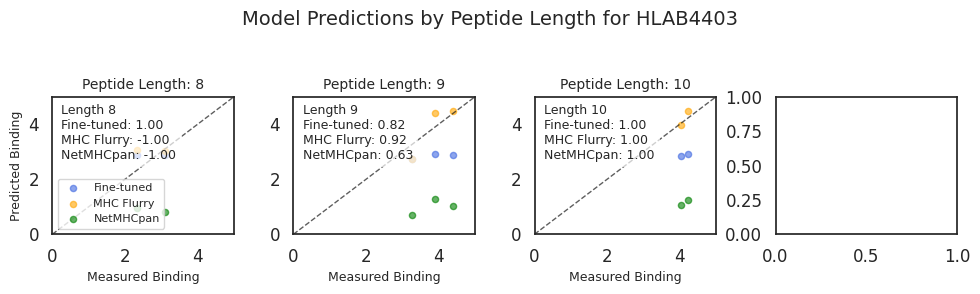

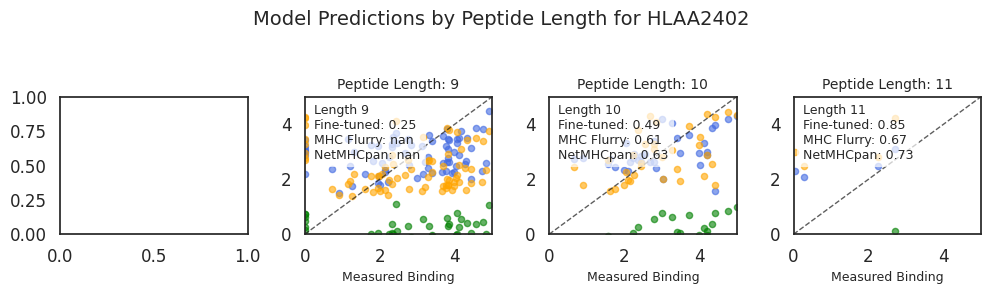

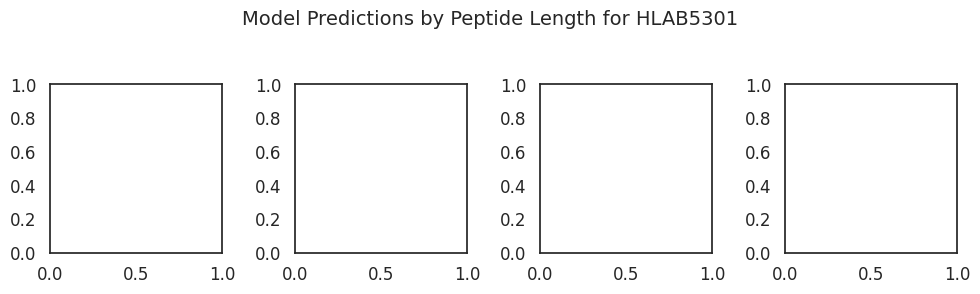

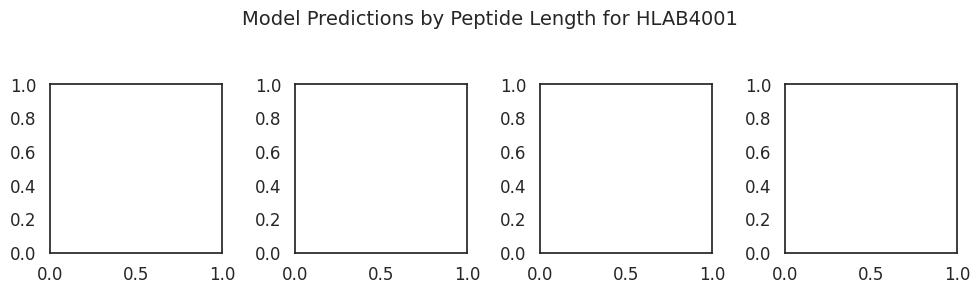

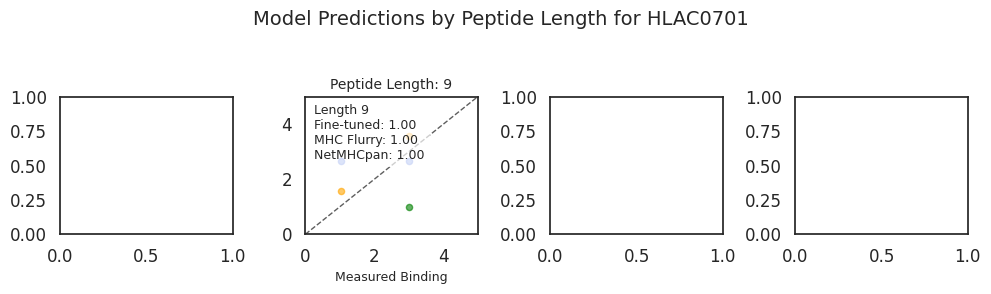

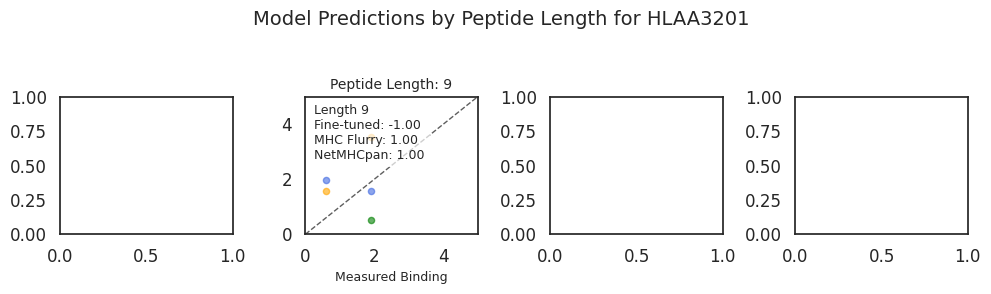

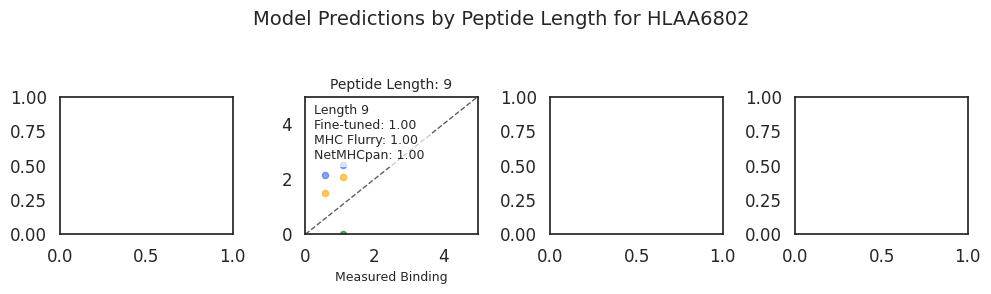

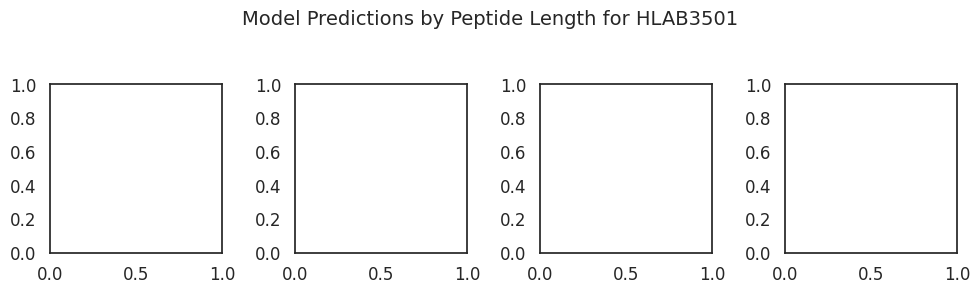

In [36]:
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

for HLA in merged_dfs_by_HLA.keys():
    predictions = merged_dfs_by_HLA[HLA]
    predictions['length'] = predictions['sequence'].str.len()
    
    fig, axes = plt.subplots(1, 4, figsize=(10, 3), sharex=False, sharey=False)  # Slightly wider figure for 3 models
    
    # Loop over the four peptide lengths.
    for idx, L in enumerate([8, 9, 10, 11]):
        ax = axes[idx]
        preds_length = predictions[predictions['length'] == L]

        if len(preds_length) < 2:
            continue

        if preds_length.empty:
            ax.text(0.5, 0.5, f"No data for length {L}", ha='center', va='center')
            ax.set_title(f"Length {L}")
            continue
            
        if 'mhc_log' not in preds_length.columns:
            continue
        if 'netmhc_log' not in preds_length.columns:
            continue
        
        # Fine-tuned predictions
        ax.scatter(preds_length['measured'], preds_length['prediction'], 
                   color='royalblue', alpha=0.6, s=20, label='Fine-tuned')
        # MHC Flurry predictions (log-transformed)
        ax.scatter(preds_length['measured'], preds_length['mhc_log'], 
                   color='orange', alpha=0.6, s=20, label='MHC Flurry')
        # NetMHCpan predictions (log-transformed)
        ax.scatter(preds_length['measured'], preds_length['netmhc_log'], 
                   color='green', alpha=0.6, s=20, label='NetMHCpan')
        
        # Determine common limits for the x=y line.
        all_vals = np.concatenate([
            preds_length['measured'].values, 
            preds_length['prediction'].values,
            preds_length['mhc_log'].values,
            preds_length['netmhc_log'].values
        ])
        min_val, max_val = np.min(all_vals), np.max(all_vals)
        pad = (max_val - min_val) * 0.05
        lims = [min_val - pad, max_val + pad]
        ax.plot([0, 5], [0, 5], 'k--', alpha=0.7, lw=1)
        ax.set_xlim([0, 5])
        ax.set_ylim([0, 5])
        
        # Compute Spearman correlations for each model.
        sp_finetuned, _ = pearsonr(preds_length['measured'], preds_length['prediction'])
        sp_mhc, _       = pearsonr(preds_length['measured'], preds_length['mhc_log'])
        sp_netmhc, _    = pearsonr(preds_length['measured'], preds_length['netmhc_log'])
        
        # Annotate the panel with Spearman correlation values.
        annotation = (f"Length {L}\n"
                      f"Fine-tuned: {sp_finetuned:.2f}\n"
                      f"MHC Flurry: {sp_mhc:.2f}\n"
                      f"NetMHCpan: {sp_netmhc:.2f}")
        ax.text(0.05, 0.95, annotation, transform=ax.transAxes,
                verticalalignment='top', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        ax.set_title(f"Peptide Length: {L}", fontsize=10)
        if idx == 0:
            ax.set_ylabel("Predicted Binding", fontsize=9)
        ax.set_xlabel("Measured Binding", fontsize=9)
        if idx == 0:
            ax.legend(fontsize=8)
    
    fig.suptitle(f"Model Predictions by Peptide Length for {HLA}", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # Save the figure with the HLA name in the specified folder.
    save_path = f'/global/scratch/users/sergiomar10/data/figures_presentation/{HLA}.png'
    # plt.savefig(save_path, dpi=300)
    # plt.close(fig)
    plt.show()

In [37]:
combined_df = pd.concat(merged_dfs_by_HLA.values(), ignore_index=True)
combined_df.to_csv("../../performances/predictions_of_models.csv", index=False)

: 

### Qualitative peptides benchmark

In [38]:
IEDB_full = pd.read_csv('/global/scratch/users/sergiomar10/ESMCBA/mhc_ligand_table_export_1727815227.tsv', sep = '\t', header = 0)
IEDB_full.head()

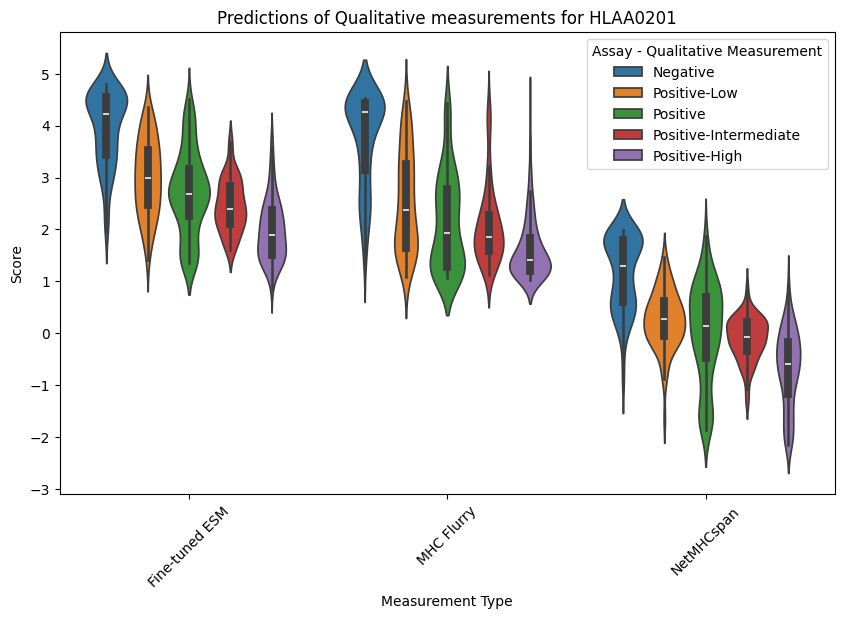

In [ ]:
IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLA-A*02:01']
IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
labeled_combined = pd.merge(left = combined_df[combined_df['HLA'] == 'HLAA0201'], right = IEDB_full_subset, left_on='sequence', right_on ='Epitope - Name')

df_melted = pd.melt(
    labeled_combined,
    id_vars=['Assay - Qualitative Measurement'],
    value_vars=['prediction', 'mhc_log', 'netmhc_log'],
    var_name='Measurement Type',
    value_name='Score'
)

# Create violinplot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_melted,
    x='Measurement Type',
    y='Score',
    hue='Assay - Qualitative Measurement',
    hue_order= ['Negative', 'Positive-Low', 'Positive', 'Positive-Intermediate', 'Positive-High'],
    split=False  # optional: split violins if there are only 2 hue levels
)
plt.xticks([0, 1, 2],labels=['Fine-tuned ESM', 'MHC Flurry', 'NetMHCspan'], rotation=45)
plt.title("Predictions of Qualitative measurements for HLAA0201")
plt.show()

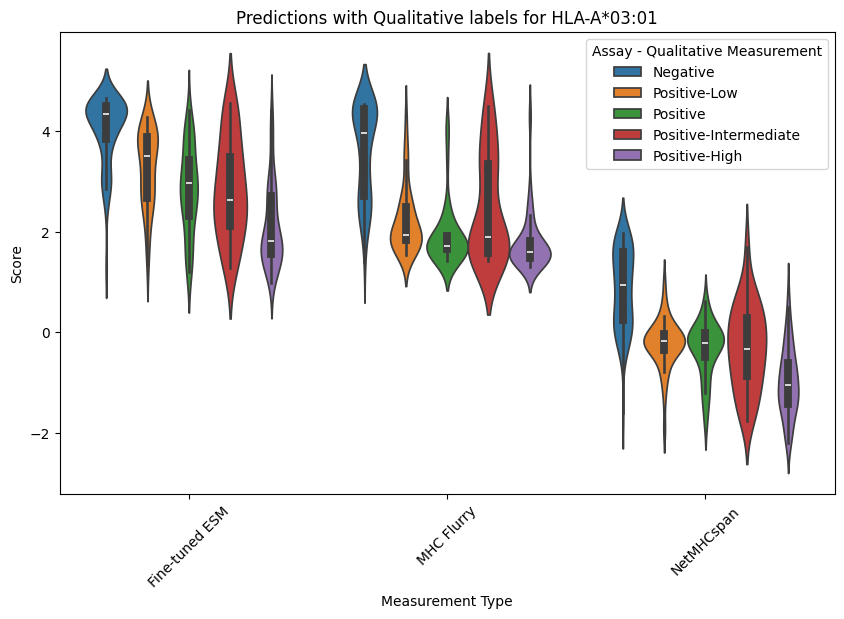

In [ ]:
IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLA-A*03:01']
IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
labeled_combined = pd.merge(left = combined_df[combined_df['HLA'] == 'HLAA0301'], right = IEDB_full_subset, left_on='sequence', right_on ='Epitope - Name')

df_melted = pd.melt(
    labeled_combined,
    id_vars=['Assay - Qualitative Measurement'],
    value_vars=['prediction', 'mhc_log', 'netmhc_log'],
    var_name='Measurement Type',
    value_name='Score'
)

# Create violinplot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_melted,
    x='Measurement Type',
    y='Score',
    hue='Assay - Qualitative Measurement',
    hue_order= ['Negative', 'Positive-Low', 'Positive', 'Positive-Intermediate', 'Positive-High'],
    split=False  # optional: split violins if there are only 2 hue levels
)
plt.xticks([0, 1, 2],labels=['Fine-tuned ESM', 'MHC Flurry', 'NetMHCspan'], rotation=45)
plt.title("Predictions with Qualitative labels for HLA-A*03:01")
plt.show()

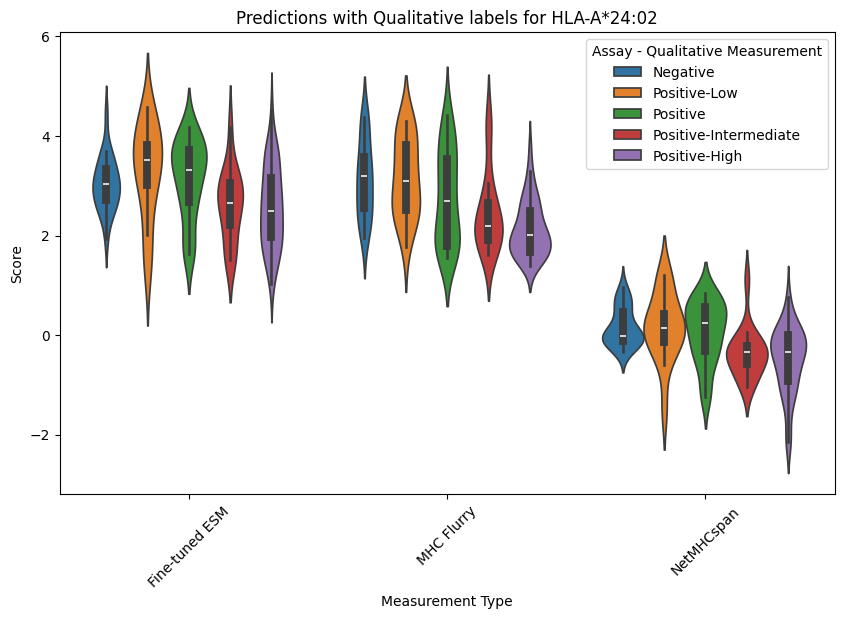

In [ ]:
IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLA-A*24:02']
IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
labeled_combined = pd.merge(left = combined_df[combined_df['HLA'] == 'HLAA2402'], right = IEDB_full_subset, left_on='sequence', right_on ='Epitope - Name')

df_melted = pd.melt(
    labeled_combined,
    id_vars=['Assay - Qualitative Measurement'],
    value_vars=['prediction', 'mhc_log', 'netmhc_log'],
    var_name='Measurement Type',
    value_name='Score'
)

# Create violinplot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_melted,
    x='Measurement Type',
    y='Score',
    hue='Assay - Qualitative Measurement',
    hue_order= ['Negative', 'Positive-Low', 'Positive', 'Positive-Intermediate', 'Positive-High'],
    split=False  # optional: split violins if there are only 2 hue levels
)
plt.xticks([0, 1, 2],labels=['Fine-tuned ESM', 'MHC Flurry', 'NetMHCspan'], rotation=45)
plt.title("Predictions with Qualitative labels for HLA-A*24:02")
plt.show()

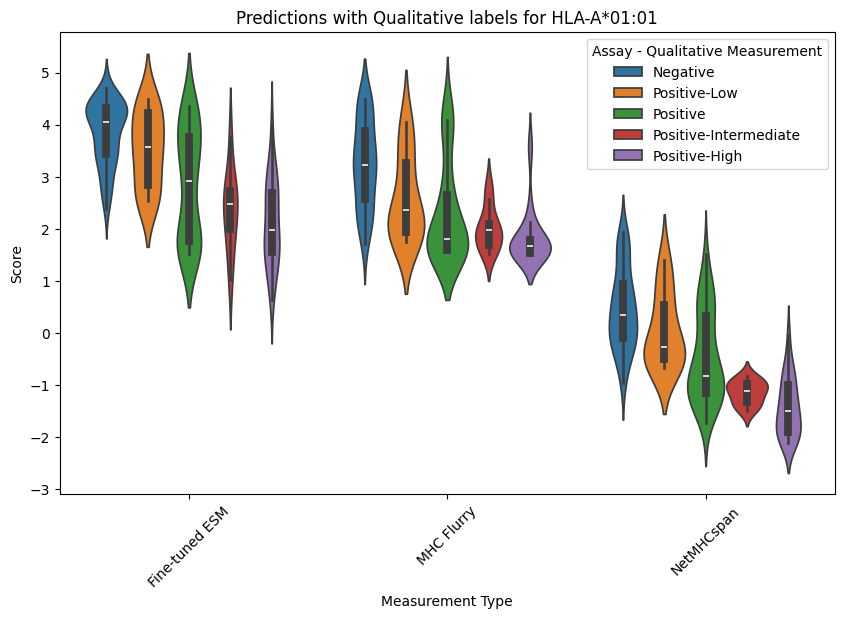

In [ ]:
IEDB_full_subset = IEDB_full[IEDB_full['MHC Restriction - Name'] == 'HLA-A*01:01']
IEDB_full_subset = IEDB_full_subset[['Epitope - Name', 'Assay - Qualitative Measurement']]
labeled_combined = pd.merge(left = combined_df[combined_df['HLA'] == 'HLAA0101'], right = IEDB_full_subset, left_on='sequence', right_on ='Epitope - Name')

df_melted = pd.melt(
    labeled_combined,
    id_vars=['Assay - Qualitative Measurement'],
    value_vars=['prediction', 'mhc_log', 'netmhc_log'],
    var_name='Measurement Type',
    value_name='Score'
)

# Create violinplot
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_melted,
    x='Measurement Type',
    y='Score',
    hue='Assay - Qualitative Measurement',
    hue_order= ['Negative', 'Positive-Low', 'Positive', 'Positive-Intermediate', 'Positive-High'],
    split=False  # optional: split violins if there are only 2 hue levels
)
plt.xticks([0, 1, 2],labels=['Fine-tuned ESM', 'MHC Flurry', 'NetMHCspan'], rotation=45)
plt.title("Predictions with Qualitative labels for HLA-A*01:01")
plt.show()